In [29]:
import pandas as pd
import matplotlib.pyplot as plt

# === CONFIG ===
initial_capital = 1000
daily_budget = 30
N = 3  # top & bottom

# === COSTI DI TRANSAZIONE ===
FEE_RATE = 0.00045     # 0.045% per lato (taker)
SPREAD   = 0.0005      # 0.05%
SLIPPAGE = 0.0005      # 0.05%

In [30]:

# ============================================================
# =============== FUNZIONE COSTI DI TRANSAZIONE ===============
# ============================================================

def apply_transaction_costs(side, op, cp, fee_rate=FEE_RATE, spread=SPREAD, slippage=SLIPPAGE):
    """
    side: 'LONG' o 'SHORT'
    op, cp: prezzi "puliti" (senza costi)
    ritorna:
      effective_op, effective_cp, ret (netto slippage/spread), fee_pct (percentuale sul notional)
    """
    impair = spread + slippage

    if side == "LONG":
        effective_op = op * (1 + impair)
        effective_cp = cp * (1 - impair)
        ret = (effective_cp - effective_op) / effective_op
    else:  # SHORT
        effective_op = op * (1 - impair)
        effective_cp = cp * (1 + impair)
        ret = (effective_op - effective_cp) / effective_op

    fee_pct = fee_rate * 2  # open + close

    return effective_op, effective_cp, ret, fee_pct



In [31]:

# ============================================================
# ================= LOAD PREZZI GIORNALIERI ===================
# ============================================================

ranks = pd.read_csv("../data/ranks.csv", parse_dates=["release_date"])
prices = pd.read_csv("../data/perps_prices_19.csv", parse_dates=["time"])

prices["date"] = prices["time"].dt.date
ranks["date"]  = ranks["release_date"].dt.date

ranks  = ranks.sort_values("date")
prices = prices.sort_values("date")

unique_days = sorted(ranks["date"].unique())



In [32]:

# ============================================================
# ========== LOAD FUNDING ORARIO + ORACLE ORARIO =============
# ============================================================

funding = pd.read_csv("../data/all_perps_hourly_funding.csv")
oracle  = pd.read_csv("../data/oracle_price.csv")

# datetime robusto (formati misti, con/senza microsecondi)
funding["time"] = pd.to_datetime(funding["time"], utc=True, format="mixed")
oracle["time"]  = pd.to_datetime(oracle["time"],  utc=True, format="mixed")

# tronca ai secondi e togli timezone
funding["time"] = funding["time"].dt.floor("s").dt.tz_convert(None)
oracle["time"]  = oracle["time"].dt.floor("s").dt.tz_convert(None)

# merge semplice su perp + time (ora sono allineati)
funding_oracle = funding.merge(
    oracle,
    on=["perp", "time"],
    how="inner",
    validate="m:1"   # ogni funding time per perp ha 1 oracle
)

# (opzionale) controllino rapido
print("Funding rows:", len(funding))
print("Funding+Oracle matched rows:", len(funding_oracle))


Funding rows: 768749
Funding+Oracle matched rows: 749901


In [33]:
# ============================================================
# ============= FUNZIONE FUNDING (VETTORIALE) =================
# ============================================================

def compute_funding_payment(token, start, end, position_size_asset):
    """
    Calcola funding totale per una posizione tra start (incluso) ed end (escluso).
    Usa funding_oracle già fuso (fundingRate + oraclePx).
    """
    mask = (
        (funding_oracle["perp"] == token) &
        (funding_oracle["time"] >= start) &
        (funding_oracle["time"] <  end)
    )
    f_slice = funding_oracle.loc[mask]

    if f_slice.empty:
        return 0.0

    # Vectorized: fundingRate * oraclePx * size_asset e somma
    return (f_slice["fundingRate"] * f_slice["oraclePx"] * position_size_asset).sum()

In [34]:

# ============================================================
# ======================= BACKTEST ============================
# ============================================================

trades = []
equity = initial_capital
equity_curve = []
cash_curve = []
capital_invested = 0

open_positions = []
daily_positions = []

# ========================= MAIN LOOP =========================

for day in unique_days:

    # ---- 1. Chiudi posizioni con scadenza oggi ----
    positions_to_close = [p for p in open_positions if p["close_ts"].date() == day]
    day_pnl = 0.0

    for pos in positions_to_close:

        # funding pagato/recevuto durante tutta la posizione
        funding_cashflow = compute_funding_payment(
            token=pos["token"],
            start=pos["open_ts"],
            end=pos["close_ts"],
            position_size_asset=pos["position_size_asset"]
        )

        total_pnl = pos["pnl_no_funding"] + funding_cashflow

        # libera capitale
        capital_invested -= pos["position_size_eur"]

        day_pnl += total_pnl

        open_positions.remove(pos)

    # ---- 2. Seleziona i top/bottom del giorno ----
    day_df = ranks[ranks["date"] == day]

    topN = day_df.nlargest(N, "pred_30d")
    botN = day_df.nsmallest(N, "pred_30d")

    candidates = []

    # LONG
    for _, row in topN.iterrows():
        token = row["id"]
        open_date = row["date"]
        close_date = open_date + pd.Timedelta(days=30)

        op_series = prices[(prices["date"] == open_date) & (prices["perp"] == token)]["close"]
        cp_series = prices[(prices["date"] == close_date) & (prices["perp"] == token)]["close"]

        if op_series.empty or cp_series.empty:
            continue

        candidates.append({
            "token": token,
            "side": "LONG",
            "open_price": op_series.iloc[0],
            "close_price": cp_series.iloc[0],
            "open_date": open_date,
            "close_date": close_date
        })

    # SHORT
    for _, row in botN.iterrows():
        token = row["id"]
        open_date = row["date"]
        close_date = open_date + pd.Timedelta(days=30)

        op_series = prices[(prices["date"] == open_date) & (prices["perp"] == token)]["close"]
        cp_series = prices[(prices["date"] == close_date) & (prices["perp"] == token)]["close"]

        if op_series.empty or cp_series.empty:
            continue

        candidates.append({
            "token": token,
            "side": "SHORT",
            "open_price": op_series.iloc[0],
            "close_price": cp_series.iloc[0],
            "open_date": open_date,
            "close_date": close_date
        })

    # ---- 3. Budget giornaliero ----
    n_pos = len(candidates)
    position_size = daily_budget / n_pos if n_pos > 0 else 0.0

    daily_positions.append({"date": day, "positions": n_pos})

    # ---- 4. Apri posizioni con costi integrati ----
    for pos in candidates:

        op = pos["open_price"]
        cp = pos["close_price"]

        effective_op, effective_cp, ret, fee_pct = apply_transaction_costs(
            pos["side"], op, cp
        )

        # fee monetarie
        fees = position_size * fee_pct

        pnl_no_funding = position_size * ret - fees
        capital_invested += position_size

        # size in asset = notional / prezzo di apertura (effettivo)
        position_size_asset = position_size / effective_op

        open_ts  = pd.Timestamp(pos["open_date"])
        close_ts = pd.Timestamp(pos["close_date"])

        open_positions.append({
            "token": pos["token"],
            "side": pos["side"],
            "position_size_eur": position_size,
            "position_size_asset": position_size_asset,
            "open_ts": open_ts,
            "close_ts": close_ts,
            "pnl_no_funding": pnl_no_funding
        })

        trades.append({
            "token": pos["token"],
            "side": pos["side"],
            "open_date": pos["open_date"],
            "close_date": pos["close_date"],
            "open_price": op,
            "close_price": cp,
            "effective_open": effective_op,
            "effective_close": effective_cp,
            "position_size": position_size,
            "return": ret,
            "fees": fees,
            "pnl_eur_no_funding": pnl_no_funding  # NOTA: solo trade PnL senza funding
        })

    # ---- 5. Aggiorna equity ----
    equity += day_pnl

    # ---- 6. Liquidità ----
    cash = equity - capital_invested

    equity_curve.append({"date": day, "equity": equity})
    cash_curve.append({"date": day, "cash": cash})



In [35]:

# ============================================================
# ===================== OUTPUT & METRICHE =====================
# ============================================================

equity_df = pd.DataFrame(equity_curve)
cash_df   = pd.DataFrame(cash_curve)
trades_df = pd.DataFrame(trades)

# (opzionale) calcolo funding per trade per logging
funding_list = []
pnl_with_funding_list = []

for _, tr in trades_df.iterrows():
    token = tr["token"]
    start = pd.Timestamp(tr["open_date"])
    end   = pd.Timestamp(tr["close_date"])

    # size asset ricavata dal notional e effective_open
    pos_size_asset = tr["position_size"] / tr["effective_open"]

    f_cash = compute_funding_payment(token, start, end, pos_size_asset)
    funding_list.append(f_cash)
    pnl_with_funding_list.append(tr["pnl_eur_no_funding"] + f_cash)

trades_df["funding"] = funding_list
trades_df["pnl_eur"] = pnl_with_funding_list  # ora pnl_eur = pnl totale (trade + funding)

# Ritorno totale in €
total_return_eur = equity - initial_capital

# Ritorno percentuale totale
total_return_pct = (equity / initial_capital - 1) * 100

# Ritorno medio per trade (in €)
avg_pnl_trade = trades_df["pnl_eur"].mean()

# Ritorno percentuale medio per trade
avg_return_pct_trade = trades_df["return"].mean() * 100

# Win rate
win_rate = (trades_df["pnl_eur"] > 0).mean() * 100

# Statistiche sulla distribuzione dei ritorni trade-by-trade
mean_ret   = trades_df["return"].mean() * 100
median_ret = trades_df["return"].median() * 100
std_ret    = trades_df["return"].std() * 100

metrics = pd.DataFrame({
    "metric": [
        "Final Equity (€)",
        "Total Return (€)",
        "Total Return (%)",
        "Avg PnL per Trade (€)",
        "Avg Return per Trade (%)",
        "Win Rate (%)",
        "Mean Return per Trade (%)",
        "Median Return per Trade (%)",
        "Std Return per Trade (%)",
        "Number of Trades"
    ],
    "value": [
        equity,
        total_return_eur,
        total_return_pct,
        avg_pnl_trade,
        avg_return_pct_trade,
        win_rate,
        mean_ret,
        median_ret,
        std_ret,
        len(trades_df)
    ]
})

print("\n================ METRICHE =================\n")
print(metrics.to_string(index=False))




================ METRICHE =================

                     metric       value
           Final Equity (€) 1093.151671
           Total Return (€)   93.151671
           Total Return (%)    9.315167
      Avg PnL per Trade (€)    0.104783
   Avg Return per Trade (%)    3.497064
               Win Rate (%)   55.680540
  Mean Return per Trade (%)    3.497064
Median Return per Trade (%)    3.686872
   Std Return per Trade (%)   27.454432
           Number of Trades  889.000000


In [36]:

# ============================================================
# ====== STATISTICHE SUL NUMERO DI POSIZIONI GIORNALIERE =====
# ============================================================

daily_pos_df = pd.DataFrame(daily_positions)

days_with_10   = (daily_pos_df["positions"] == 2*N).sum()
days_with_less = ((daily_pos_df["positions"] > 0) & (daily_pos_df["positions"] < 2*N)).sum()
days_with_zero = (daily_pos_df["positions"] == 0).sum()

print("\n=========== STATISTICHE POSIZIONI GIORNALIERE ===========\n")
print(f"Giorni con {2*N} posizioni aperte: {days_with_10}")
print(f"Giorni con meno di {2*N} posizioni: {days_with_less}")
print(f"Giorni senza alcuna posizione: {days_with_zero}")

summary_pos = pd.DataFrame({
    "Category": [f"{2*N} positions", "1–{2*N - 1} positions", "0 positions"],
    "Days": [days_with_10, days_with_less, days_with_zero]
})

print("\nTabella riepilogo:")
print(summary_pos.to_string(index=False))




=========== STATISTICHE POSIZIONI GIORNALIERE ===========

Giorni con 6 posizioni aperte: 139
Giorni con meno di 6 posizioni: 11
Giorni senza alcuna posizione: 30

Tabella riepilogo:
             Category  Days
          6 positions   139
1–{2*N - 1} positions    11
          0 positions    30


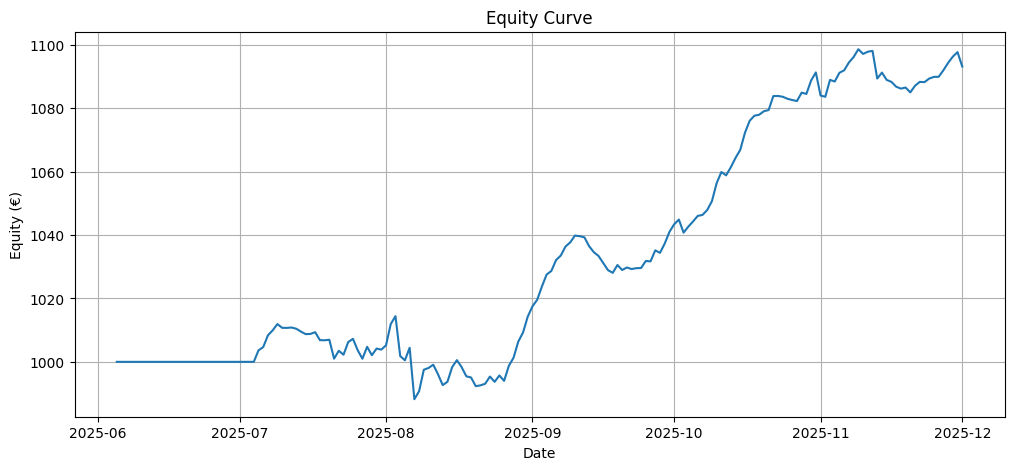

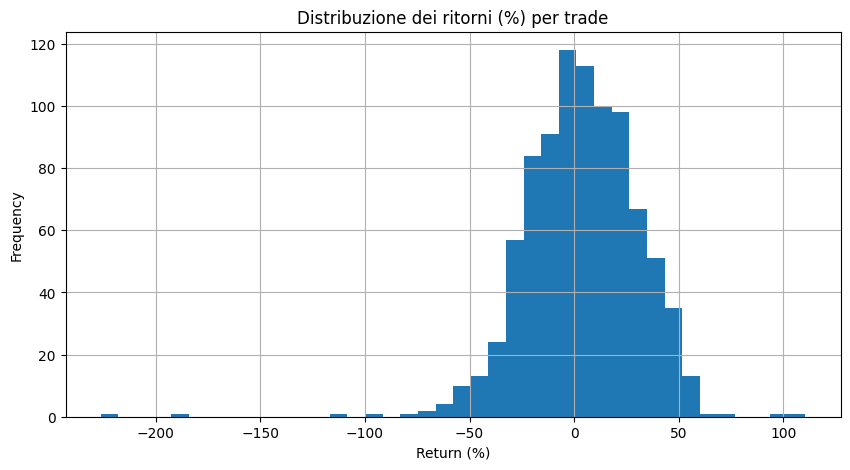

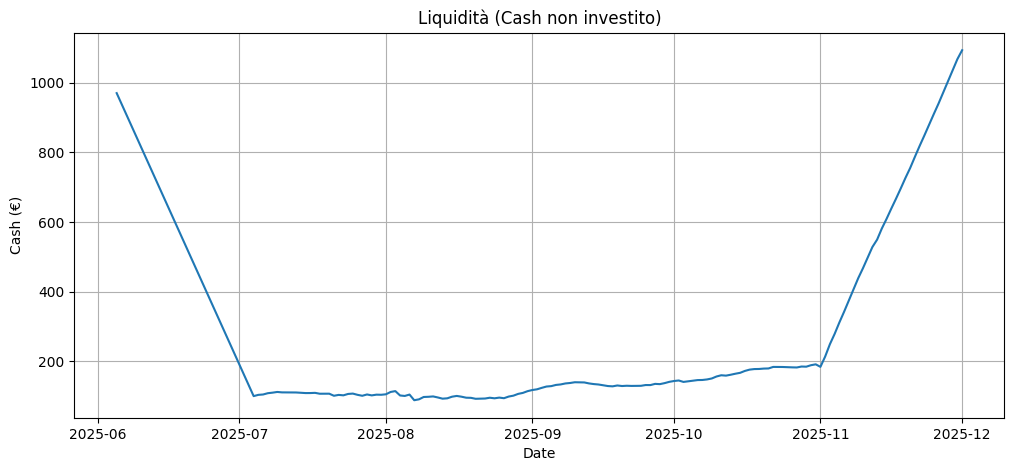


File CSV salvato correttamente: ../data/trades_export.csv


In [37]:

# ============================================================
# ======================== GRAFICI ============================
# ============================================================

plt.figure(figsize=(12,5))
plt.plot(equity_df["date"], equity_df["equity"])
plt.title("Equity Curve")
plt.xlabel("Date")
plt.ylabel("Equity (€)")
plt.grid()
plt.show()

plt.figure(figsize=(10,5))
plt.hist(trades_df["return"] * 100, bins=40)
plt.title("Distribuzione dei ritorni (%) per trade")
plt.xlabel("Return (%)")
plt.ylabel("Frequency")
plt.grid()
plt.show()

plt.figure(figsize=(12,5))
plt.plot(cash_df["date"], cash_df["cash"])
plt.title("Liquidità (Cash non investito)")
plt.xlabel("Date")
plt.ylabel("Cash (€)")
plt.grid()
plt.show()

# ============================================================
# ===================== EXPORT TRADES =========================
# ============================================================
output_filename = "../data/trades_export.csv"
trades_df.to_csv(output_filename, index=False)

print(f"\nFile CSV salvato correttamente: {output_filename}")



In [38]:
import pandas as pd
import matplotlib.pyplot as plt

# === LOAD TRADES ===
trades_df = pd.read_csv("../data/trades_export.csv", parse_dates=["open_date", "close_date"])


# =============================
# PnL LONG / SHORT
# =============================

pnl_long_total = trades_df[trades_df["side"] == "LONG"]["pnl_eur"].sum()
pnl_short_total = trades_df[trades_df["side"] == "SHORT"]["pnl_eur"].sum()

print("PnL LONG:", pnl_long_total)
print("PnL SHORT:", pnl_short_total)


# =============================
# Win rate long / Loss rate short
# =============================

# LONG won = pnl > 0
long_trades = trades_df[trades_df["side"] == "LONG"]
short_trades = trades_df[trades_df["side"] == "SHORT"]

# LONG won = pnl > 0
long_win_rate = (long_trades["pnl_eur"] > 0).mean() * 100
short_win_rate = (short_trades["pnl_eur"] > 0).mean() * 100

print(f"Long win rate:   {long_win_rate:.2f}%")
print(f"Short win rate:  {short_win_rate:.2f}%")

PnL LONG: -50.975564832314134
PnL SHORT: 144.12723596265693
Long win rate:   42.47%
Short win rate:  68.92%


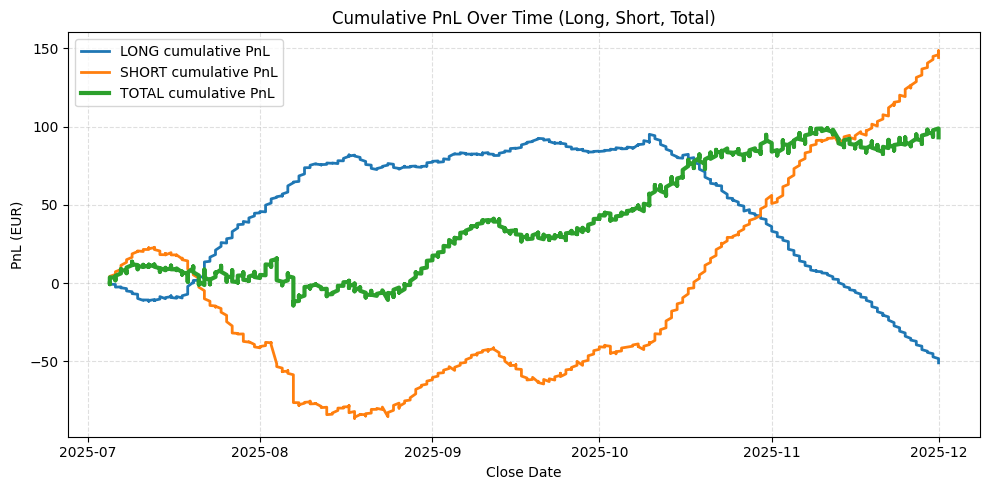

In [39]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Load ---
trades_df = pd.read_csv("../data/trades_export.csv", parse_dates=["open_date", "close_date"])

# --- Sort by close date ---
trades_df = trades_df.sort_values("close_date")

# --- Separate long & short ---
long_df = trades_df[trades_df["side"] == "LONG"].copy()
short_df = trades_df[trades_df["side"] == "SHORT"].copy()

# --- Compute cumulative PnL for LONG & SHORT ---
long_df["cumulative_pnl"] = long_df["pnl_eur"].cumsum()
short_df["cumulative_pnl"] = short_df["pnl_eur"].cumsum()

# --- Compute TOTAL cumulative PnL ---
trades_df["cumulative_total"] = trades_df["pnl_eur"].cumsum()

# ============================
#     PLOT CUMULATIVE ONLY  
# ============================
plt.figure(figsize=(10,5))

plt.plot(long_df["close_date"], long_df["cumulative_pnl"], label="LONG cumulative PnL", linewidth=2)
plt.plot(short_df["close_date"], short_df["cumulative_pnl"], label="SHORT cumulative PnL", linewidth=2)

# NEW: combined PnL curve
plt.plot(trades_df["close_date"], trades_df["cumulative_total"], 
         label="TOTAL cumulative PnL", linewidth=3)

plt.title("Cumulative PnL Over Time (Long, Short, Total)")
plt.xlabel("Close Date")
plt.ylabel("PnL (EUR)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()
